In [1]:
import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec, LayerSpecs
from ihp import PDK

PDK.activate()

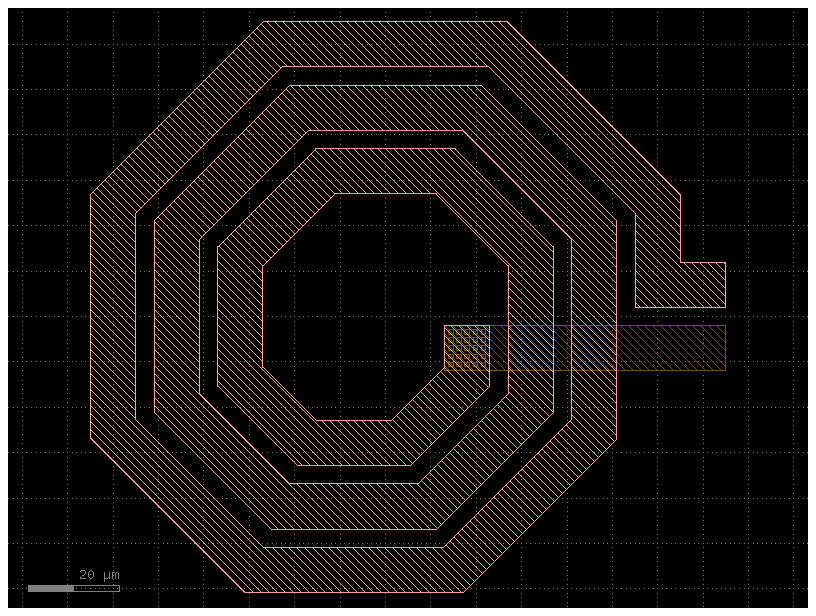

In [2]:
c = gf.import_gds("~/Documents/gsim/nbs/inductors/spiral_inductor.gds")
c.plot()

In [3]:
import math
from primitives import (
    map_y,
    scale_y,
    via_grid,
    pgs_strips,
)

In [4]:
@gf.cell
def spiral_inductor(
    outer_diameter: float = 130.0,
    turns: int = 3,
    sides: int = 8,
    width: float = 10.0,
    spacing: float = 4.0,
    via_spacing: float = 0.8,
    via_width: float = 1.0,
    via_enclosure: float = 0.45,
    aspect_ratio: float = 1.0,
    port_side: str = "same",
    add_pgs: bool = False,
    pgs_diameter: float = 120.0,
    pgs_width: float = 4.0,
    pgs_spacing: float = 2.0,
    layer_winding: LayerSpec = "TopMetal2drawing",
    layer_underpass: LayerSpec = "TopMetal1drawing",
    layer_via: LayerSpec = "TopVia2drawing",
    layers_pgs: LayerSpecs = ("TopMetal1drawing",),
) -> Component:
    """Polygonal spiral inductor.

    A single-layer winding polygon is drawn on layer_winding. The inner
    terminal is brought out through an underpass on layer_underpass,
    connected by a via array on layer_via.

    Args:
        outer_diameter: Outer diameter of the spiral in micrometers.
        turns: Number of complete turns.
        sides: Number of polygon sides per full turn (8 = octagonal).
        width: Metal trace width in micrometers.
        spacing: Gap between adjacent turns in micrometers.
        via_spacing: Gap between individual via squares in micrometers.
        via_width: Side length of each via square in micrometers.
        via_enclosure: Minimum metal enclosure around each via in micrometers.
        aspect_ratio: Y-axis scale factor for non-square spirals (1.0 = symmetric).
        port_side: Exit port placement — ``"same"`` keeps both ports on the same
            side; ``"opposite"`` places them on opposite sides.
        add_pgs: When True, horizontal strips forming a patterned ground
            shield are added on layers_pgs.
        pgs_diameter: Bounding diameter of the ground shield in micrometers.
        pgs_width: Strip width of each ground shield finger in micrometers.
        pgs_spacing: Gap between adjacent ground shield fingers in micrometers.
        layer_winding: Metal layer for the main spiral winding.
        layer_underpass: Metal layer for the inner-terminal underpass bridge.
        layer_via: Via layer connecting winding to underpass.
        layers_pgs: Layers on which the patterned ground shield is drawn.

    Returns:
        Component with 2 RF ports:
          P1  ->  entry terminal  (layer_winding)
          P2  ->  exit terminal   (layer_underpass)
    """
    c = Component()
    PI = math.pi
    opposite = port_side == "opposite"

    # Derived parameters
    s = (spacing + width) / math.cos(PI / sides)  # turn-to-turn pitch (polar)
    v = width / math.cos(PI / sides)  # radial trace width
    R1 = outer_diameter / 2 / math.cos(PI / sides)  # outer polygon radius
    R2 = R1 - v  # inner polygon radius

    # Sampling angles per half-turn
    n_pts = sides // 2
    angles = [
        PI * (1 / (2 * n_pts) + i * (1 - 1 / n_pts) / (n_pts - 1)) for i in range(n_pts)
    ]

    extend = 2 * (via_width + via_enclosure) + via_spacing
    x_shift = -s / 2 * math.cos(PI / sides)
    y_shift_ = -s / 2 * math.sin(PI / sides)
    sy = scale_y(aspect_ratio)

    # Build spiral vertices half-turn by half-turn
    x_out, y_out, x_in, y_in = [], [], [], []
    r1, r2 = R1, R2

    for section in range(2 * turns - 1 if opposite else 2 * turns):
        if section % 2 == 0:  # right-hand half-turn
            for phi in angles:
                x_out.append(r1 * math.cos(phi))
                x_in.append(r2 * math.cos(phi))
                y_out.append(r1 * math.sin(phi))
                y_in.append(r2 * math.sin(phi))
        else:  # left-hand half-turn (shifted)
            for phi in angles:
                x_out.append(-r1 * math.cos(phi) + x_shift)
                x_in.append(-r2 * math.cos(phi) + x_shift)
                y_out.append(-r1 * math.sin(phi) + y_shift_)
                y_in.append(-r2 * math.sin(phi) + y_shift_)
        r1 -= s / 2
        r2 -= s / 2

    # Winding polygon (main metal trace)
    entry_yc = 0.0 if opposite else (width + spacing) / 2
    exit_yc = 0.0 if opposite else -(width + spacing) / 2
    y_end = [-width / 2 if opposite else -spacing / 2]

    x_poly = (
        [outer_diameter / 2 + width, x_out[0]]
        + x_out
        + [x_out[-1]]
        + list(reversed([x_in[-1]]))
        + list(reversed(x_in))
        + list(reversed([outer_diameter / 2 + width, x_in[0]]))
    )
    y_poly = (
        [entry_yc + width / 2] * 2
        + y_out
        + y_end
        + list(reversed(y_end))
        + list(reversed(y_in))
        + [entry_yc - width / 2] * 2
    )

    winding = map_y(list(zip(x_poly, y_poly)), sy)

    # Underpass polygon (lower-metal bridge for inner terminal)
    underpass_end_x = (
        -(outer_diameter / 2 + width) if opposite else outer_diameter / 2 + width
    )
    last_x_in, last_x_out = x_in[-1], x_out[-1]

    underpass = map_y(
        [
            (last_x_in, exit_yc - width / 2),
            (underpass_end_x, exit_yc - width / 2),
            (underpass_end_x, exit_yc + width / 2),
            (last_x_in, exit_yc + width / 2),
        ],
        sy,
    )

    # Via array connecting winding layer to underpass layer
    via_cx = last_x_out + (last_x_in - last_x_out) / 2
    via_cy = exit_yc
    if extend > width:
        raw_vias = via_grid(
            via_cx,
            via_cy + (extend - width) / 2,
            width - 2 * via_enclosure,
            extend - 2 * via_enclosure,
            via_spacing,
            via_width,
        )
    else:
        raw_vias = via_grid(
            via_cx,
            via_cy,
            width - 2 * via_enclosure,
            width - 2 * via_enclosure,
            via_spacing,
            via_width,
        )

    # Add polygons to component
    c.add_polygon(winding, layer=layer_winding)
    c.add_polygon(underpass, layer=layer_underpass)
    for via in [map_y(p, sy) for p in raw_vias]:
        c.add_polygon(via, layer=layer_via)

    if add_pgs:
        for layer in layers_pgs:
            for strip in pgs_strips(pgs_diameter, pgs_width, pgs_spacing):
                c.add_polygon(map_y(strip, sy), layer=layer)

    # Ports
    c.add_port(
        "P1",
        center=(outer_diameter / 2 + width, sy(entry_yc)),
        width=width,
        orientation=0.0,
        layer=layer_winding,
    )
    c.add_port(
        "P2",
        center=(underpass_end_x, sy(exit_yc)),
        width=width,
        orientation=180.0,
        layer=layer_underpass,
    )

    return c

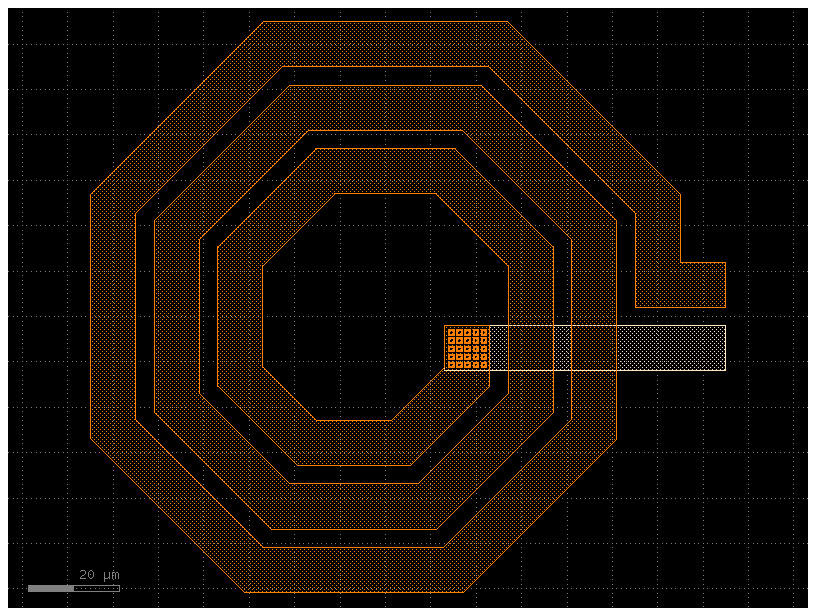

In [13]:
cc = spiral_inductor()
cc.plot()

In [6]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-spiral_inductor")

# Set the component geometry
sim.set_geometry(cc)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# Configure ports
sim.add_port("P1", layer="topmetal2", geometry="inplane", excited=True)
sim.add_port("P2", layer="topmetal1", geometry="inplane", excited=True)
# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [7]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=1.5)
sim.write_config()

Info    : Reading 'palace-sim-spiral_inductor/palace.msh'...
Info    : 29844 nodes
Info    : 216357 elements
Info    : Done reading 'palace-sim-spiral_inductor/palace.msh'                                                   
Info    : Reading 'palace-sim-spiral_inductor/palace.msh'...
Info    : 29844 nodes
Info    : 216357 elements
Info    : Done reading 'palace-sim-spiral_inductor/palace.msh'                                                   


PosixPath('palace-sim-spiral_inductor/config.json')

In [8]:
sim.plot_mesh(show_groups=["metal", "via", "P"])

Widget(value='<iframe src="http://localhost:39681/index.html?ui=P_0x7f0538391cd0_0&reconnect=auto" class="pyvi…

In [9]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "sio2__None", "air__sio2"],
)

Widget(value='<iframe src="http://localhost:39681/index.html?ui=P_0x7f05801cc230_1&reconnect=auto" class="pyvi…

In [10]:
# Run simulation on GDSFactory+ cloud
results = sim.run(parent_dir="./palace-sim-spiral_inductor")

  palace-ce4a546b  completed  6m 08s
Extracting results.tar.gz...
Downloaded 10 files to palace-sim-spiral_inductor/sim-data-palace-ce4a546b


In [11]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2
